In [14]:
import os
import numpy as np
from matplotlib import pylab as plt           
from IPython import get_ipython
import matplotlib
from scipy.optimize import curve_fit


In [ ]:
#paramtètre global 
#file_path = r"potentiel_quadrupole.npz"
file_path =r"potentiel_quadrupole_VF.npz"
a = 3.4934e-1
e = 1.6e-19 #C  charge élémentaire 


Vacc=20000 #V
Vq2=-0.0299087*Vacc
Vapert1=-0.18808*Vacc
Vapert2=0.10918*Vacc

In [16]:
# Implémentation de la fonction RK4 utilisé pour résoudre les equa diffs
def RK4_step(f, y, t, h, alpha, beta):
    f1 = f(y, t, alpha, beta)
    f2 = f(y + h*f1/2, t + h/2, alpha, beta)
    f3 = f(y + h*f2/2, t + h/2, alpha, beta)
    f4 = f(y + h*f3, t + h, alpha, beta)
    
    y_next = y + (h/6)*(f1 + 2*f2 + 2*f3 + f4)
    return y_next

In [ ]:
#reation d'une class ion que l'on va utiliser pour nos différents rayons
#Création de la class quadrupole et simulateur 

class potentiel_data:
    def __init__(self, file_path):
        data = np.load(file_path)
        self.points = data["points"]
        self.axe_z = self.points[2]
        self.phi0 = data["potential"][0] #en V
        self.E = data["E_eval"] #en V/mm
        self.D2 = data["D2_eval"] # en V/mm^2
        self.D3 = data["D3_eval"]
        self.D4 = data["D4_eval"]
        self.dimension = data["dimensions"]
        #self.va = data["Va"]
        #self.vq = data("Vq")

        '''
        dimension : 
        dist shiel aperture
        dis aperture quad 
        radiux ext shield
        radius inter shiled 
        thickeness shield 
        dimension radius aperture
        thickness aperture
        lenght cylinder
        radius axis
        total lenght

        '''





class ion:
    def __init__(self, mass,charge,name, x =0, v = 0):
        self.mass = mass
        self.charge=charge
        self.name=name

        self.state_x = np.array([x, v]) #position et  vitesse de la particule
        self.history_x = []# tableau qui enregiste les positions en cours du temps (utilisé avec self_step) pour pouvoir tracer 

        self.state_y = np.array([x, v]) #position et  vitesse de la particule
        self.history_y = []# tableau qui enregiste les positions en cours du temps (utilisé avec self_step) pour pouvoir tracer 

    def afficher_detail(self):
        print(f"ion: {self.mass}, charge : {self.charge}, nom : {self.name}")

    def save_step(self): 
        self.history_x.append(self.state_x[0]) #sauvegarde la position , (pourquoi pas suavagrder la vitesse pour regarder son évolution)
        self.history_y.append(self.state_y[0])

    
    


#utlisation de nos données importante pour créer notre quads 
class quadrupole :
    def __init__(self, potentiel, radius_a):
        self.axe_z = potentiel.axe_z
        self.phi0 = potentiel.phi0
        self.a = radius_a
    def décomposition(self,potentiel):
        self.phi0 = potentiel.phi0*Vapert1
        self.phi2 = (1/self.a**2) * (1/8 (potentiel.D2[0] - potentiel.D2[3]))*Vq2
        self.phi3 = (1/self.a**3) * (1/8 * (1/24)*(potentiel.D3[0] - 3*potentiel.D3[3]))
        self.phi4= (1/self.a**4) * (1/192 * (1/192)*(potentiel.D4[0] + potentiel.D4[10] - 6*potentiel.D4[3]))*Vapert1
   
        self.D2zphi0 = potentiel.D2[5]
        self.D1zphi0 = potentiel.E[2]
    
        

    
#simule la trajectoire d'un ion dans notre quadrupole
class simulateur :

    def equation(self, y, t, alpha, beta):
        u = y[0] # position radiale
        v = y[1] # pente
        du = v
        dv = -alpha * u - beta * v
        return np.array([du, dv])

    def simulation(self, ion, quad):

        #phi_ref = quad.phi0[0]
        dz_mm = quad.axe_z[1] - quad.axe_z[0]
        dz_m = dz_mm * 1e-3  # Conversion en mètres
        X = np.zeros(np.size(quad.phi2))


        for i in range(len(quad.axe_z)-1):
            ion.save_step() #on enregiste la position 

                

            alphax = quad.D2zphi0[i] / (4 * quad.phi0[i]) - quad.phi2[i] / quad.phi0[i]
            alphay = quad.D2zphi0[i] / (4 * quad.phi0[i]) + quad.phi2[i] / quad.phi0[i]

            beta = quad.D1zphi0[i]/(2*quad.phi0[i])
            
           
            #beta = 0      # Pas d'accélération longitudinale

            
            ion.state_x = RK4_step(self.equation, ion.state_x, quad.axe_z[i], dz_m, alphax, beta) #intégration numérique pour resoudre equadif ordre 2 
            ion.state_y = RK4_step(self.equation, ion.state_y, quad.axe_z[i], dz_m, alphay, beta)


        


        

            

            
        

Fonction décompostion, utilise les fonctions de axel pour faire la décomposition du potentiel 

In [18]:
potentiel = potentiel_data(file_path) 
quad1 = quadrupole(potentiel, a)
quad1.décomposition(potentiel)

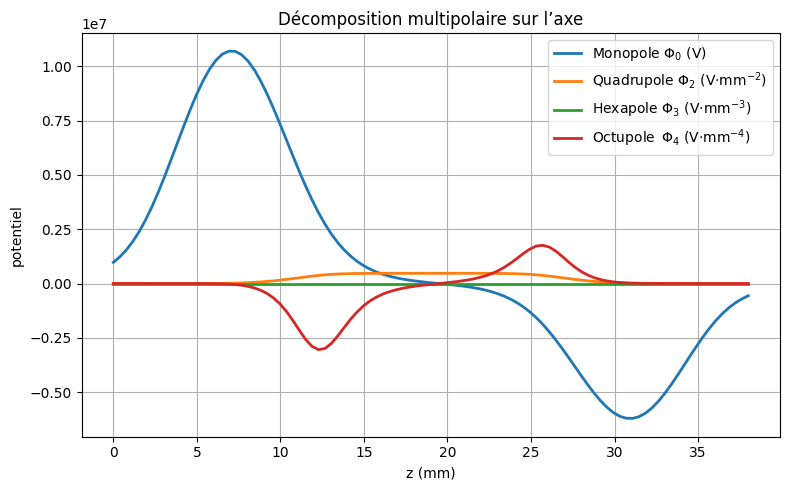

In [27]:
plt.figure(figsize=(8,5))
plt.plot(potentiel.axe_z, quad1.phi0, lw=2, label=r'Monopole $\Phi_0$ (V)')
plt.plot(potentiel.axe_z, quad1.phi2, lw=2, label=r'Quadrupole $\Phi_2$ (V·mm$^{-2}$)')
plt.plot(potentiel.axe_z, quad1.phi3, lw=2, label=r'Hexapole $\Phi_3$ (V·mm$^{-3}$)')
plt.plot(potentiel.axe_z, quad1.phi4, lw=2, label=r'Octupole $\,\Phi_4$ (V·mm$^{-4}$)')
plt.xlabel("z (mm)")
plt.ylabel("potentiel")
plt.title("Décomposition multipolaire sur l’axe")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Normalisation de phi2

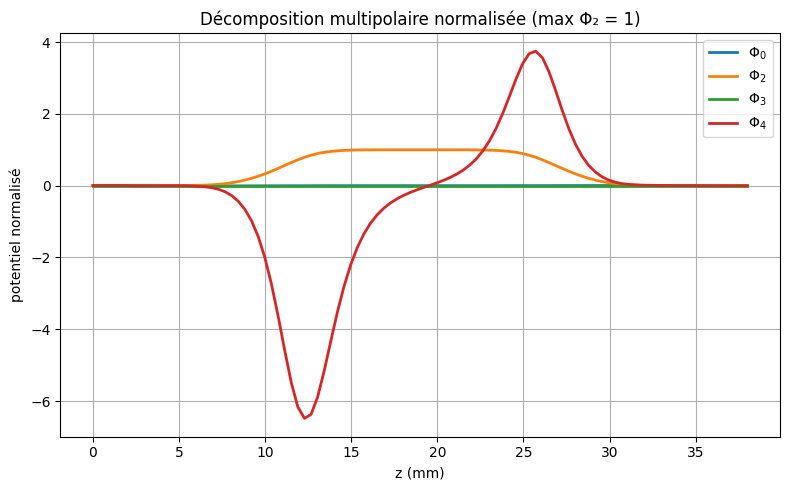

In [28]:
# facteur de normalisation
phi2_max = np.max(np.abs(quad1.phi2))

# potentiels normalisés
phi0_n = potentiel.phi0 / phi2_max
phi2_n = quad1.phi2 / phi2_max
phi3_n = quad1.phi3 / phi2_max
phi4_n = quad1.phi4 / phi2_max
plt.figure(figsize=(8,5))

plt.plot(potentiel.axe_z, phi0_n, lw=2, label=r'$\Phi_0$')
plt.plot(potentiel.axe_z, phi2_n, lw=2, label=r'$\Phi_2$ ')
plt.plot(potentiel.axe_z, phi3_n, lw=2, label=r'$\Phi_3$')
plt.plot(potentiel.axe_z, phi4_n, lw=2, label=r'$\Phi_4$')

plt.xlabel("z (mm)")
plt.ylabel("potentiel normalisé")
plt.title("Décomposition multipolaire normalisée (max Φ₂ = 1)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


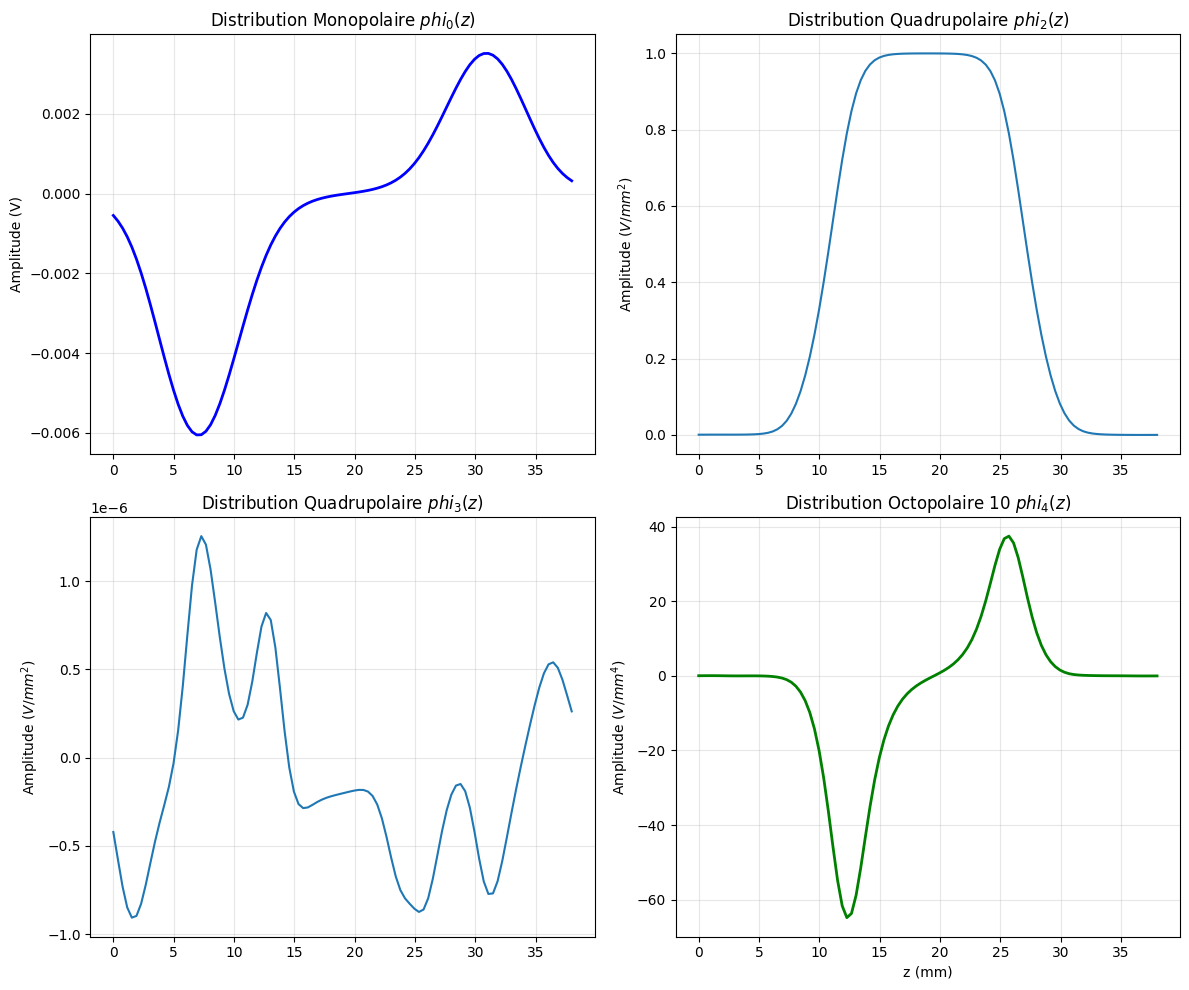

In [29]:

# Configuration de la figure 2x2
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# ---  phi (Monopole) ---
axs[0, 0].plot(potentiel.axe_z, phi0_n, lw=2, color='blue')
axs[0, 0].set_title("Distribution Monopolaire $phi_0(z)$")
axs[0, 0].set_ylabel("Amplitude (V)")
axs[0, 0].grid(True, alpha=0.3)

# ---  phi2 (Quadrupole) ---
axs[0, 1].plot(potentiel.axe_z, phi2_n)
axs[0, 1].set_title("Distribution Quadrupolaire $phi_2(z)$")
axs[0, 1].set_ylabel("Amplitude ($V/mm^2$)")
axs[0, 1].grid(True, alpha=0.3)
# ---  phi3 (Quadrupole) ---
axs[1, 0].plot(potentiel.axe_z, phi3_n)
axs[1, 0].set_title("Distribution Quadrupolaire $phi_3(z)$")
axs[1, 0].set_ylabel("Amplitude ($V/mm^2$)")
axs[1, 0].grid(True, alpha=0.3)

# ---  100*phi4 (Octupole) ---
axs[1, 1].plot(potentiel.axe_z, 10 * phi4_n, lw=2, color='green')
axs[1, 1].set_title("Distribution Octopolaire $10 \ phi_4(z)$")
axs[1, 1].set_xlabel("z (mm)")
axs[1, 1].set_ylabel("Amplitude ($V/mm^4$)")
axs[1, 1].grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

Utilisation les fonctions du papier d'okayama pour retrouver nos différentes symétrie
Avec la même valeur de variable que Okayama

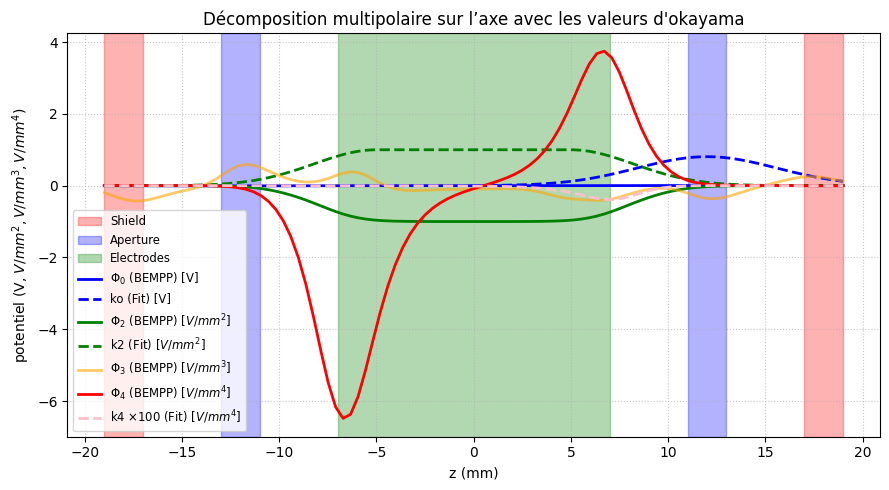

'\ndef extraction (Data):\n    #Extraction des dimensions du quadrupole pour les tracer sur le graphe \n    deb_shield1 = 0\n    fin_shield1 = Data.dimension[4]\n\n    deb_ap1 = fin_shield1 + Data.dimension[0]\n    fin_ap1 = deb_ap1 + Data.dimension[6]\n\n    deb_cyl = fin_ap1 + Data.dimension[1]\n    fin_cyl = deb_cyl + Data.dimension[7]\n    milieu_cyl = deb_cyl + Data.dimension[9]/2\n\n    deb_ap2 = fin_cyl + Data.dimension[1]\n    fin_ap2 = deb_ap2 + Data.dimension[6]\n\n    deb_shield2 = fin_ap2 + Data.dimension[0]\n    fin_shield2 = deb_shield2 + Data.dimension[4]\n    \n    fig, ax = plt.subplots(figsize=(9, 5))\n\n    ax.axvspan(deb_shield1, fin_shield1, color=\'red\', alpha=0.3, label=\'Shield\')\n    ax.axvspan(deb_ap1, fin_ap1, color=\'blue\', alpha=0.3, label=\'Aperture\')\n    ax.axvspan(deb_cyl, fin_cyl, color=\'green\', alpha=0.3, label=\'Electrodes\')\n    ax.axvspan(deb_ap2, fin_ap2, color=\'blue\', alpha=0.3)\n    ax.axvspan(deb_shield2, fin_shield2, color=\'red\', al

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def fonction_fit(z,Data):
    # --- axe z ---
    z = Data.axe_z

    # --- Dimensions ---
    deb_shield1 = 0
    fin_shield1 = Data.dimension[4]

    deb_ap1 = fin_shield1 + Data.dimension[0]
    fin_ap1 = deb_ap1 + Data.dimension[6]

    deb_cyl = fin_ap1 + Data.dimension[1]
    fin_cyl = deb_cyl + Data.dimension[7]

    milieu_cyl = 0.5 * (deb_cyl + fin_cyl)

    deb_ap2 = fin_cyl + Data.dimension[1]
    fin_ap2 = deb_ap2 + Data.dimension[6]

    deb_shield2 = fin_ap2 + Data.dimension[0]
    fin_shield2 = deb_shield2 + Data.dimension[4]

    #on translate tout 

    z = z - milieu_cyl

    deb_shield1 -= milieu_cyl
    fin_shield1 -= milieu_cyl
    deb_ap1 -= milieu_cyl
    fin_ap1 -= milieu_cyl
    deb_cyl -= milieu_cyl
    fin_cyl -= milieu_cyl
    deb_ap2 -= milieu_cyl
    fin_ap2 -= milieu_cyl
    deb_shield2 -= milieu_cyl
    fin_shield2 -= milieu_cyl

    z_quad_center = 0                          # on trace à partir du milieu du cylindre
    z_quad_edge   = + Data.dimension[7]/2     # bord du cylindre
    z_ap_center   = z_quad_edge + Data.dimension[1] + Data.dimension[6]/2

    Z_k2 = z - z_quad_center     # quadrupôle
    Z_k4 = z - z_quad_edge       # octupôle
    Z_k0 = z - z_ap_center       # lentille ronde



    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.axvspan(deb_shield1, fin_shield1, color='red', alpha=0.3, label='Shield')
    ax.axvspan(deb_ap1, fin_ap1, color='blue', alpha=0.3, label='Aperture')
    ax.axvspan(deb_cyl, fin_cyl, color='green', alpha=0.3, label='Electrodes')
    ax.axvspan(deb_ap2, fin_ap2, color='blue', alpha=0.3)
    ax.axvspan(deb_shield2, fin_shield2, color='red', alpha=0.3)


    # --- k0 ---
    a0, b = 0.80751, 5.08
    k0 = a0 * np.exp(-(Z_k0**2) / b**2)

    # --- k2 ---
    Z0, b2 = 5, 4.54
    k2 = np.where(
    np.abs(Z_k2) <= Z0,
    1,
    np.exp(-(np.abs(Z_k2) - Z0)**2 / b2**2)
)

    # --- k4 ---
    a4, b1, b2 = 0.03891461, 3.113, 2.015
    k4 = np.where(Z_k4 <= 0, a4 / (1 + (Z_k4**2 / b1**2))**2,
    a4 * np.exp(-(Z_k4**2) / b2**2)
)

  
    



    # --- Tracé avec unités ---
    # Phi0 et k0 sont en Volts [V]
    plt.plot(z, phi0_n, lw=2, label=r'$\Phi_0$ (BEMPP) [V]', color='blue')
    plt.plot(z, k0, lw=2, label=r'ko (Fit) [V]', linestyle='--', color='blue')

    # Phi2 et k2 sont en [V/mm²]
    plt.plot(z, -phi2_n, lw=2, label=r'$\Phi_2$ (BEMPP) [$V/mm^2$]', color='green')
    plt.plot(z, k2, lw=2, label=r'k2 (Fit) [$V/mm^2$]', linestyle='--', color='green')

    # Phi3
    plt.plot(z, quad1.phi3, lw=2, label=r'$\Phi_3$ (BEMPP) [$V/mm^3$]', color='orange', alpha=0.6)

    # Phi4 et k4 sont en [V/mm⁴]
    plt.plot(z, 10*phi4_n, lw=2, label=r'$\Phi_4 $ (BEMPP) [$V/mm^4$]', color="red")
    plt.plot(z, -10*k4, lw=2, label=r'k4 $\times 100$ (Fit) [$V/mm^4$]', linestyle='--', color="pink")

    # --- Configuration des axes ---
    plt.xlabel("z (mm)")
    plt.ylabel("potentiel (V, $V/mm^2, V/mm^3, V/mm^4$)")
    plt.title("Décomposition multipolaire sur l’axe avec les valeurs d'okayama")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='best', fontsize='small')
    plt.tight_layout()
    plt.show()

    return k0, k2, k4


ax_Z = quad1.axe_z
# Calcul des fonctions fit
k0, k2, k4 = fonction_fit(ax_Z, potentiel)

'''
def extraction (Data):
    #Extraction des dimensions du quadrupole pour les tracer sur le graphe 
    deb_shield1 = 0
    fin_shield1 = Data.dimension[4]

    deb_ap1 = fin_shield1 + Data.dimension[0]
    fin_ap1 = deb_ap1 + Data.dimension[6]

    deb_cyl = fin_ap1 + Data.dimension[1]
    fin_cyl = deb_cyl + Data.dimension[7]
    milieu_cyl = deb_cyl + Data.dimension[9]/2

    deb_ap2 = fin_cyl + Data.dimension[1]
    fin_ap2 = deb_ap2 + Data.dimension[6]

    deb_shield2 = fin_ap2 + Data.dimension[0]
    fin_shield2 = deb_shield2 + Data.dimension[4]
    
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.axvspan(deb_shield1, fin_shield1, color='red', alpha=0.3, label='Shield')
    ax.axvspan(deb_ap1, fin_ap1, color='blue', alpha=0.3, label='Aperture')
    ax.axvspan(deb_cyl, fin_cyl, color='green', alpha=0.3, label='Electrodes')
    ax.axvspan(deb_ap2, fin_ap2, color='blue', alpha=0.3)
    ax.axvspan(deb_shield2, fin_shield2, color='red', alpha=0.3)
    



    # --- Tracé avec unités ---
    # Phi0 et k0 sont en Volts [V]
    plt.plot(ax_Z, phi0_n, lw=2, label=r'$\Phi_0$ (BEMPP) [V]', color='blue')
    plt.plot(ax_Z, k0, lw=2, label=r'ko (Fit) [V]', linestyle='--', color='blue')

    # Phi2 et k2 sont en [V/mm²]
    plt.plot(ax_Z, -phi2_n, lw=2, label=r'$\Phi_2$ (BEMPP) [$V/mm^2$]', color='green')
    plt.plot(ax_Z, k2, lw=2, label=r'k2 (Fit) [$V/mm^2$]', linestyle='--', color='green')

    # Phi3 est en [V/mm³]
    plt.plot(ax_Z, quad1.phi3, lw=2, label=r'$\Phi_3$ (BEMPP) [$V/mm^3$]', color='orange', alpha=0.6)

    # Phi4 et k4 sont en [V/mm⁴]
    # On multiplie par 100 pour la visibilité comme demandé
    plt.plot(ax_Z, phi4_n, lw=2, label=r'$\Phi_4 \times 100$ (BEMPP) [$V/mm^4$]', color="red")
    plt.plot(ax_Z, 10*k4, lw=2, label=r'k4 $\times 100$ (Fit) [$V/mm^4$]', linestyle='--', color="pink")

    # --- Configuration des axes ---
    plt.xlabel("z (mm)")
    plt.ylabel("potentiel (V, $V/mm^2, V/mm^3, V/mm^4$)")
    plt.title("Décomposition multipolaire sur l’axe avec les valeurs d'okayama")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='best', fontsize='small')
    plt.tight_layout()
    plt.show()
'''

#extraction(potentiel)

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def geometrie(Data):

    
    # Dimensions
    

    l_cyl   = Data.dimension[0]
    r_cyl   = Data.dimension[1]
    t_ap    = Data.dimension[2]
    r_ap_o  = Data.dimension[3]
    r_ap_i  = Data.dimension[4]
    dist    = Data.dimension[5]
    d_sh_ap = Data.dimension[6]
    t_sh    = Data.dimension[7]
    add_sh  = Data.dimension[8]
    r_out_sh = Data.dimension[9]
    r_in_sh  = Data.dimension[10]
    L_tot    = Data.dimension[11]

    
    # Positions z (aperture à z = 0)
  

    # Aperture gauche
    z_ap_L1 = 0
    z_ap_L2 = t_ap

    # Cylindre
    z_cyl_L = z_ap_L2 + dist
    z_cyl_R = z_cyl_L + l_cyl
    z_cyl_C = 0.5 * (z_cyl_L + z_cyl_R)

    # Aperture droite
    z_ap_R1 = z_cyl_R + dist
    z_ap_R2 = z_ap_R1 + t_ap

    # Shield (autour)
    z_shield_L = z_ap_L1 - (d_sh_ap + t_sh + add_sh)
    z_shield_R = z_ap_R2 + (d_sh_ap + t_sh + add_sh)

    
    
geometrie(potentiel)

Utilisation de de la fonction curvit pour trouver les paramètres de nos fonctions fit. 


Paramètres optimisés pour ph0: a0 = 7172359.6621, b = 12.8653
Paramètres optimisés pour ph2: a0 = 4.7339, b = 4.0381
Paramètres optimisés pour ph4: a0 = -667221.1600, b1 = -802793.6352, b2 = 0.0135


/var/folders/v2/4rph4j49117dj7ww7r0xr86r0000gn/T/ipykernel_64485/2572847075.py:64: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(funck4, Z,phi4)


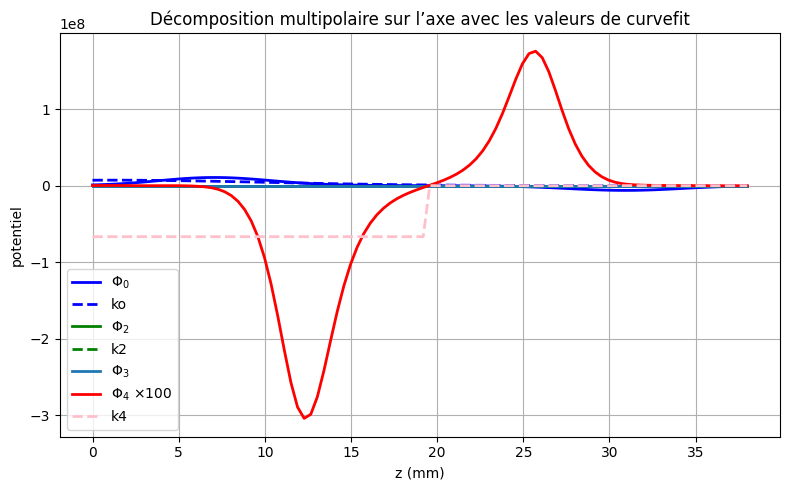

In [25]:
#Définition des 3 fonctions d'okayama dont on cherche à trouver les paramètre 
def funcko (Z, a0, b): 
    '''
    Z variable X
    Aà et b sont à déterminer 
    '''
    return a0 * np.exp(-(Z**2) / (b**2))

#je normalise pour etre à 1 
def fonction_fitphi2_normalisee(phi2_data):
    
    amplitude_max = np.max(np.abs(phi2_data))
    phi2_norm = phi2_data / amplitude_max
    return phi2_norm


def funck2(Z, Z0, b):

    zq_abs = np.absolute(Z)
    k2 = np.where(zq_abs <= Z0, 
                  1, 
                 np.exp(-(zq_abs - Z0)**2 / (b**2)))
    return k2

def funck4(Z, a4, b1, b2):
    k4 = np.where(Z <= 0, 
                  a4 / (1 + (Z / b1)**2), 
                  a4 * np.exp(-(Z**2) / (b2**2)))
    return k4

#utilisation de curve_vit, on utilise l'ordre 2 
#Pour K0, retourne les valeurs de a0, b et calcule k0
def fonction_fitphi0(z, offset_k0 ,phi0) :
    
    # --- k0 
    Z = z - offset_k0
    popt, pcov = curve_fit(funcko,Z, phi0)
    a0, b = popt
    print(f"Paramètres optimisés pour ph0: a0 = {a0:.4f}, b = {b:.4f}")
    k0_opt = funcko(Z, a0, b)
    return k0_opt, a0, b

k0, a0, b= fonction_fitphi0(quad1.axe_z, 1, quad1.phi0)


def fonction_fitphi2(z, offset_k2 ,phi2) :
    
    # --- k2 : terme quadrupolaire
    Z = z - offset_k2
    p0 = [2.4, 4.54] #donné d'okayama
    popt, pcov = curve_fit(funck2,Z, phi2)
    Z0, b = popt
    print(f"Paramètres optimisés pour ph2: a0 = {Z0:.4f}, b = {b:.4f}")
    k2_opt = funck2(Z, Z0, b)
    return k2_opt, Z0, b

phi2_norm = fonction_fitphi2_normalisee(quad1.phi2)
k2, a0, b = fonction_fitphi2 (ax_Z,19,phi2_norm)

def fonction_fitphi4(z, offset_k4, phi4):
    #-- k4 - terme octopolaire
    Z = z- offset_k4
    #Z = z
    popt, pcov = curve_fit(funck4, Z,phi4)
    a4, b1, b2 = popt
    print(f"Paramètres optimisés pour ph4: a0 = {a4:.4f}, b1 = {b1:.4f}, b2 = {b2:.4f}")
    k4_opt = funck4 (Z, a4, b1, b2)
    return k4_opt, a4, b1, b2

k4_opt , a4, b1, b2 = fonction_fitphi4(ax_Z, 19.5, quad1.phi4)


#On trace les fonctions fit 

plt.figure(figsize=(8,5))
plt.plot(ax_Z, quad1.phi0, lw=2, label=r'$\Phi_0$', color = 'blue')
plt.plot(ax_Z, k0, lw=2, label=r'ko', linestyle='--', color = 'blue')

plt.plot(ax_Z, phi2_norm, lw=2, label=r'$\Phi_2$', color = 'green')
plt.plot(ax_Z, k2, lw=2, label=r'k2', linestyle='--', color = 'green')

plt.plot(ax_Z, quad1.phi3, lw=2, label=r'$\Phi_3$')

plt.plot(ax_Z, 100*quad1.phi4, lw=2, label=r'$\Phi_4$ ×100', color = "red")
plt.plot(ax_Z, 100*k4_opt, lw=2, label=r'k4', linestyle='--', color = "pink")


plt.xlabel("z (mm)")
plt.ylabel("potentiel")
plt.title("Décomposition multipolaire sur l’axe avec les valeurs de curvefit")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()










/var/folders/v2/4rph4j49117dj7ww7r0xr86r0000gn/T/ipykernel_64485/1560887054.py:29: RuntimeWarning: overflow encountered in cosh
  yp[i] = np.cosh(w0*(z-z0))
/var/folders/v2/4rph4j49117dj7ww7r0xr86r0000gn/T/ipykernel_64485/1560887054.py:30: RuntimeWarning: overflow encountered in sinh
  ym[i] = (1/w0)*np.sinh(w0*(z-z0))


'\n#---  Selon x ---\naxs[1, 0].plot(quad1.axe_z[:-1], xm, label="Rayon Marginal")\naxs[1, 0].plot(quad1.axe_z[:-1], xp, label="Rayon Principal")\naxs[1, 0].set_title(" trajectoire théorique selon y ")\naxs[1, 0].set_xlabel("Z(mm)")\naxs[1, 0].set_ylabel("y (mm)")\naxs[1, 0].axhline(0, color=\'black\', linestyle=\'--\', alpha=0.3)\naxs[1, 0].legend()\n\n#---  Selon y ---\naxs[1, 1].plot(quad1.axe_z[:-1], ym, label="Rayon Marginal")\naxs[1, 1].plot(quad1.axe_z[:-1], yp, label="Rayon Principal")\naxs[1, 1].set_title("Simulation théorique  selon y ")\naxs[1, 1].set_xlabel("Z(mm)")\naxs[1,1].set_ylabel("y (mm)")\naxs[1, 1].axhline(0, color=\'black\', linestyle=\'--\', alpha=0.3)\naxs[1, 1].legend()\n\n'

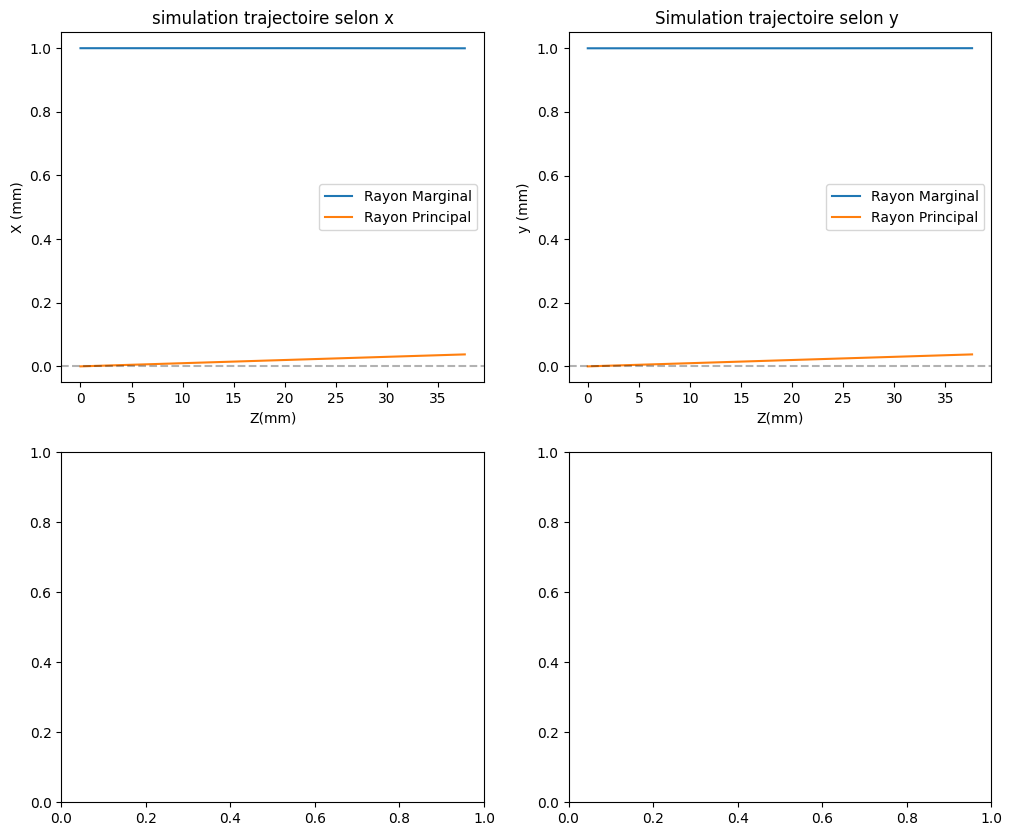

In [35]:
#initialisaation
marginal = ion(1.6e-27,e,"proton",1,0)
principal = ion(1.6e-27,e,"proton",0,1)

Ion = ion(1.6e-27,e,"proton",0,0)

# 1. Initialisation de la simulation
mon_moteur = simulateur() 

# 2. on applique pour chaque rayon
mon_moteur.simulation(marginal, quad1)
mon_moteur.simulation(principal, quad1)

def solution_analytique(ion,potentiel,quad1, z0):
        
        gamma = 1 + (ion.charge*Vacc)/(ion.mass*c**2)
        vz = c *np.sqrt(1-(1/(gamma**2))) # en m/s

        xp = np.zeros(len(potentiel.axe_z)-1)
        xm = np.zeros(len(potentiel.axe_z)-1)
        yp = np.zeros(len(potentiel.axe_z)-1)
        ym = np.zeros(len(potentiel.axe_z)-1)

        for i in range(len(potentiel.axe_z)-1):
            z = potentiel.axe_z[i]
            w0 = 1e9*(ion.charge * quad1.phi2[i]) / (2*gamma * ion.mass * vz**2)*1e-6
            xp[i] = np.cos(w0*(z-z0))
            xm[i] = (1/w0)*np.sin(w0*(z-z0))
            yp[i] = np.cosh(w0*(z-z0))
            ym[i] = (1/w0)*np.sinh(w0*(z-z0))
        return xp,xm, ym, yp

xp,xm, ym, yp = solution_analytique(Ion, potentiel,quad1, 0)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))


# ---  Selon x ---
axs[0, 0].plot(quad1.axe_z[:-1], marginal.history_x, label="Rayon Marginal")
axs[0, 0].plot(quad1.axe_z[:-1], principal.history_x, label="Rayon Principal")
axs[0, 0].set_title("simulation trajectoire selon x")
axs[0, 0].set_xlabel("Z(mm)")
axs[0, 0].set_ylabel("X (mm)")
axs[0, 0].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[0, 0].legend()

#---  Selon x ---
axs[0, 1].plot(quad1.axe_z[:-1], marginal.history_y, label="Rayon Marginal")
axs[0, 1].plot(quad1.axe_z[:-1], principal.history_y, label="Rayon Principal")
axs[0, 1].set_title("Simulation trajectoire selon y ")
axs[0, 1].set_xlabel("Z(mm)")
axs[0,1].set_ylabel("y (mm)")
axs[0, 1].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[0, 1].legend()

#solution analytique
'''
#---  Selon x ---
axs[1, 0].plot(quad1.axe_z[:-1], xm, label="Rayon Marginal")
axs[1, 0].plot(quad1.axe_z[:-1], xp, label="Rayon Principal")
axs[1, 0].set_title(" trajectoire théorique selon y ")
axs[1, 0].set_xlabel("Z(mm)")
axs[1, 0].set_ylabel("y (mm)")
axs[1, 0].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[1, 0].legend()

#---  Selon y ---
axs[1, 1].plot(quad1.axe_z[:-1], ym, label="Rayon Marginal")
axs[1, 1].plot(quad1.axe_z[:-1], yp, label="Rayon Principal")
axs[1, 1].set_title("Simulation théorique  selon y ")
axs[1, 1].set_xlabel("Z(mm)")
axs[1,1].set_ylabel("y (mm)")
axs[1, 1].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[1, 1].legend()

'''

